<a href="https://colab.research.google.com/github/Matis23ch/CasPratique/blob/main/soutenance_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importations globales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score

In [ ]:
# 1. Chargement du dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("space_missions_dataset.csv")

Saving space_missions_dataset.csv to space_missions_dataset.csv


In [ ]:
# 2. Nettoyage et préparation globale
df = df[['Mission Type', 'Target Type', 'Distance from Earth (light-years)',
         'Mission Duration (years)', 'Mission Cost (billion USD)',
         'Scientific Yield (points)', 'Crew Size', 'Fuel Consumption (tons)',
         'Payload Weight (tons)', 'Launch Vehicle', 'Mission Success (%)', 'Launch Date']]

df = df.dropna()

# Conversion de la date et extraction des infos temporelles (utile partout)
df['Launch Date'] = pd.to_datetime(df['Launch Date'])
df['Launch Year'] = df['Launch Date'].dt.year
df['Launch Month'] = df['Launch Date'].dt.month

In [ ]:
# 3. Création de la variable cible : succès si taux >= 70%
df['Success'] = df['Mission Success (%)'].apply(lambda x: 1 if x >= 70 else 0)

In [ ]:
# 4. Séparation features et target
X_clf = df[['Mission Type', 'Target Type', 'Distance from Earth (light-years)',
            'Mission Cost (billion USD)', 'Scientific Yield (points)', 'Crew Size',
            'Fuel Consumption (tons)', 'Payload Weight (tons)', 'Launch Vehicle',
            'Launch Year', 'Launch Month']]
y_clf = df['Success']

In [ ]:
# 5. Encodage et normalisation
categorical_cols = ['Mission Type', 'Target Type', 'Launch Vehicle']
numerical_cols = [col for col in X_clf.columns if col not in categorical_cols]

encoder = OneHotEncoder(sparse_output=False)
X_cat = encoder.fit_transform(X_clf[categorical_cols])

scaler = StandardScaler()
X_num = scaler.fit_transform(X_clf[numerical_cols])

X_processed_clf = np.hstack((X_cat, X_num))

In [ ]:
# 6. Train/Test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_processed_clf, y_clf, test_size=0.2, random_state=42
)

<ipython-input-11-1827828084>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Mission Type", data=df, palette='viridis')


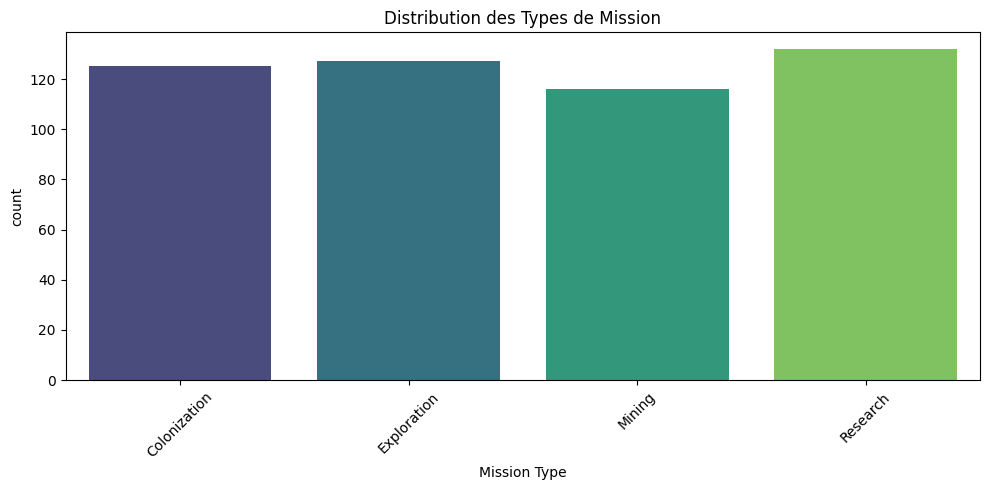

In [ ]:
# 7. Visualisation : distribution des types de mission
plt.figure(figsize=(10, 5))
sns.countplot(x="Mission Type", data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title("Distribution des Types de Mission")
plt.tight_layout()
plt.show()

In [ ]:
# 8. Modèle Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_clf)

print("Random Forest - Rapport de classification")
print(classification_report(y_test_clf, y_pred_rf_clf))
print("Matrice de confusion:")
print(confusion_matrix(y_test_clf, y_pred_rf_clf))


Random Forest - Rapport de classification
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.99      1.00      0.99        99

    accuracy                           0.99       100
   macro avg       0.49      0.50      0.50       100
weighted avg       0.98      0.99      0.99       100

Matrice de confusion:
[[ 0  1]
 [ 0 99]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# 9. Modèle Logistic Regression
log_clf = LogisticRegression(max_iter=1000)
log_clf.fit(X_train_clf, y_train_clf)
y_pred_log_clf = log_clf.predict(X_test_clf)

print("\nLogistic Regression - Rapport de classification")
print(classification_report(y_test_clf, y_pred_log_clf))
print("Matrice de confusion:")
print(confusion_matrix(y_test_clf, y_pred_log_clf))


Logistic Regression - Rapport de classification
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.99      1.00      0.99        99

    accuracy                           0.99       100
   macro avg       0.49      0.50      0.50       100
weighted avg       0.98      0.99      0.99       100

Matrice de confusion:
[[ 0  1]
 [ 0 99]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


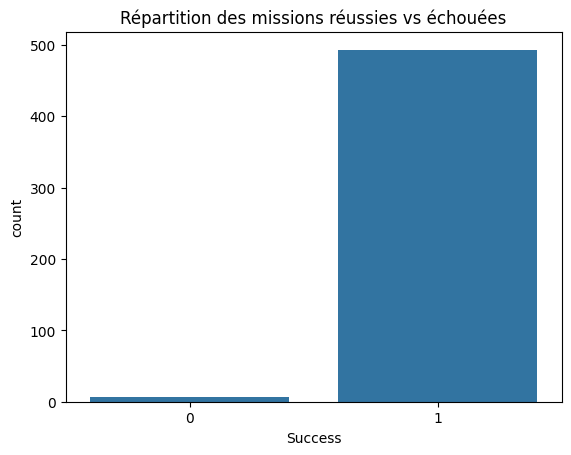

In [ ]:
# 10. Visualisation : succès vs échec
plt.figure()
sns.countplot(x="Success", data=df)
plt.title("Répartition des missions réussies vs échouées")
plt.show()

In [ ]:
# 11. Séparation features et target pour la régression
X_reg = df[['Mission Type', 'Target Type', 'Distance from Earth (light-years)',
            'Mission Cost (billion USD)', 'Scientific Yield (points)', 'Crew Size',
            'Fuel Consumption (tons)', 'Payload Weight (tons)', 'Launch Vehicle',
            'Launch Year', 'Launch Month']]
y_reg = df['Mission Duration (years)']

In [ ]:
# 12. Encodage + normalisation
X_cat_reg = encoder.transform(X_reg[categorical_cols])
X_num_reg = scaler.transform(X_reg[numerical_cols])
X_processed_reg = np.hstack((X_cat_reg, X_num_reg))

In [ ]:
# 13. Train/Test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_processed_reg, y_reg, test_size=0.2, random_state=42
)


In [ ]:
# 14. Modèle Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

print("Random Forest Regressor - RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)))
print("Random Forest Regressor - R2 score:", r2_score(y_test_reg, y_pred_rf_reg))

Random Forest Regressor - RMSE: 1.2121551220862776
Random Forest Regressor - R2 score: 0.9770860110141597


In [ ]:
# 15. Modèle Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg, y_train_reg)
y_pred_lr_reg = lr_reg.predict(X_test_reg)

print("Linear Regression - RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg)))
print("Linear Regression - R2 score:", r2_score(y_test_reg, y_pred_lr_reg))


Linear Regression - RMSE: 1.1336021563394842
Linear Regression - R2 score: 0.979959635111944


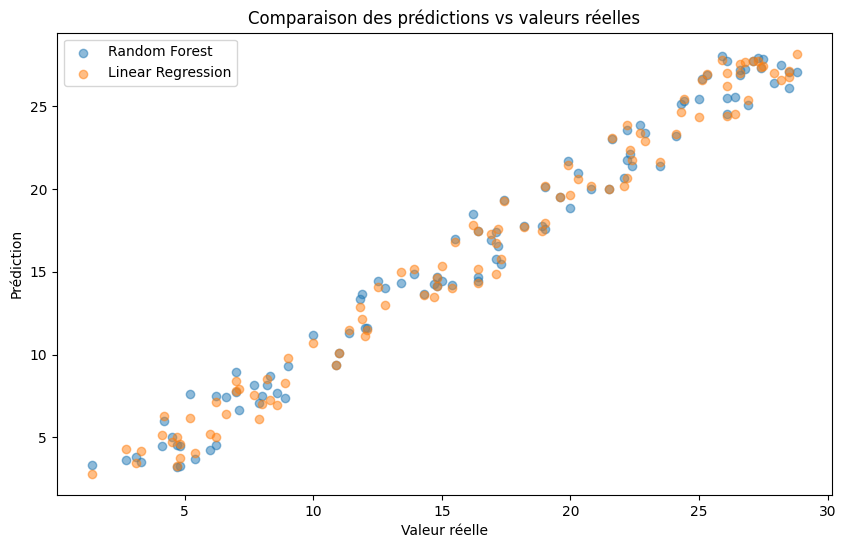

In [ ]:
# 16. Visualisation : comparaison valeurs réelles vs prédictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.5, label="Random Forest")
plt.scatter(y_test_reg, y_pred_lr_reg, alpha=0.5, label="Linear Regression")
plt.xlabel("Valeur réelle")
plt.ylabel("Prédiction")
plt.legend()
plt.title("Comparaison des prédictions vs valeurs réelles")
plt.show()

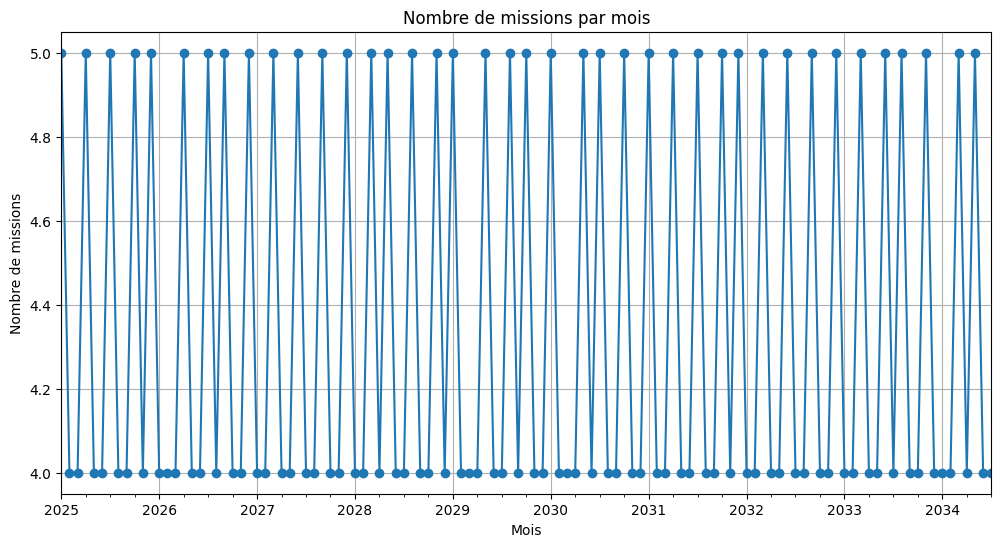

In [ ]:
# Missions par mois
df['Year-Month'] = df['Launch Date'].dt.to_period('M')
missions_per_month = df.groupby('Year-Month').size()

plt.figure(figsize=(12,6))
missions_per_month.plot(kind='line', marker='o')
plt.title("Nombre de missions par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de missions")
plt.grid(True)
plt.show()

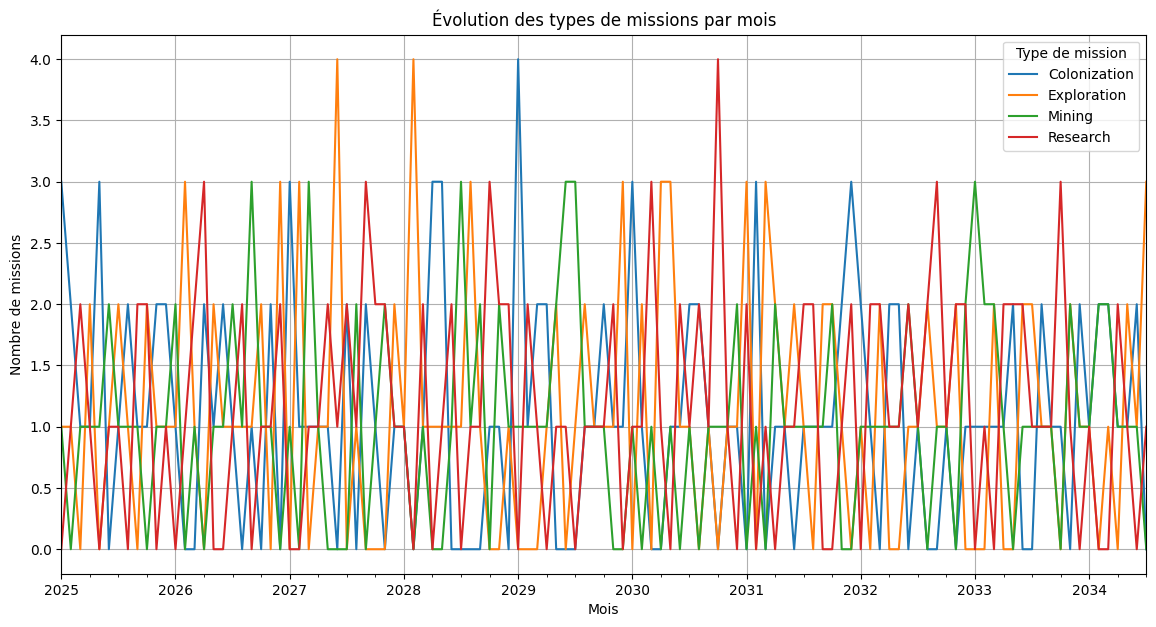

       Distance from Earth (light-years)  Mission Duration (years)  \
count                         500.000000                500.000000   
mean                           25.483060                 15.736800   
min                             0.350000                  1.400000   
25%                            11.750000                  8.900000   
50%                            26.185000                 16.400000   
75%                            38.570000                 22.200000   
max                            49.900000                 29.500000   
std                            14.942128                  7.578316   

       Mission Cost (billion USD)  Scientific Yield (points)   Crew Size  \
count                  500.000000                 500.000000  500.000000   
mean                   277.300280                  55.223400   50.118000   
min                     13.320000                  10.000000    1.000000   
25%                    149.960000                  33.775000   27

In [ ]:
# Evolution des types de missions par mois
missions_type_month = df.groupby(['Year-Month', 'Mission Type']).size().unstack().fillna(0)
missions_type_month.plot(kind='line', figsize=(14,7))
plt.title("Évolution des types de missions par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de missions")
plt.legend(title='Type de mission')
plt.grid(True)
plt.show()
print(df.describe())

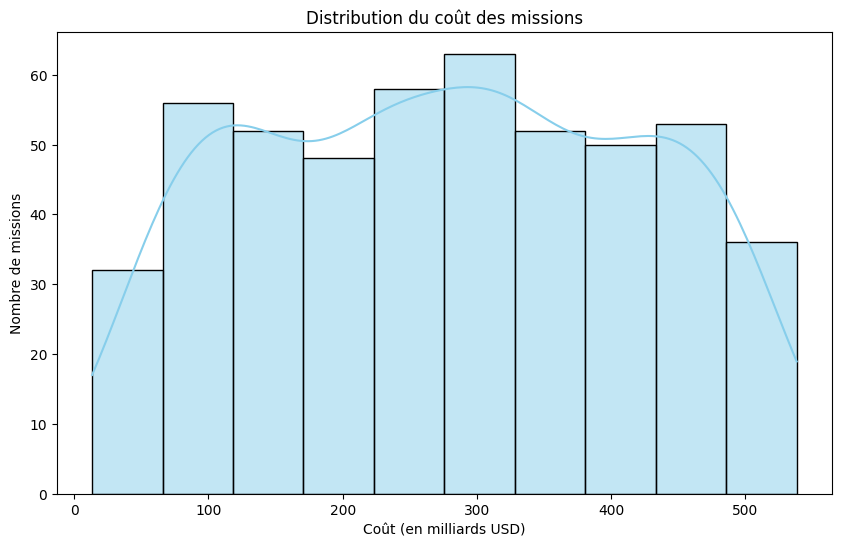

In [ ]:
# Distribution du coût des missions
plt.figure(figsize=(10, 6))
sns.histplot(df['Mission Cost (billion USD)'], kde=True, color='skyblue')
plt.title("Distribution du coût des missions")
plt.xlabel("Coût (en milliards USD)")
plt.ylabel("Nombre de missions")
plt.show()

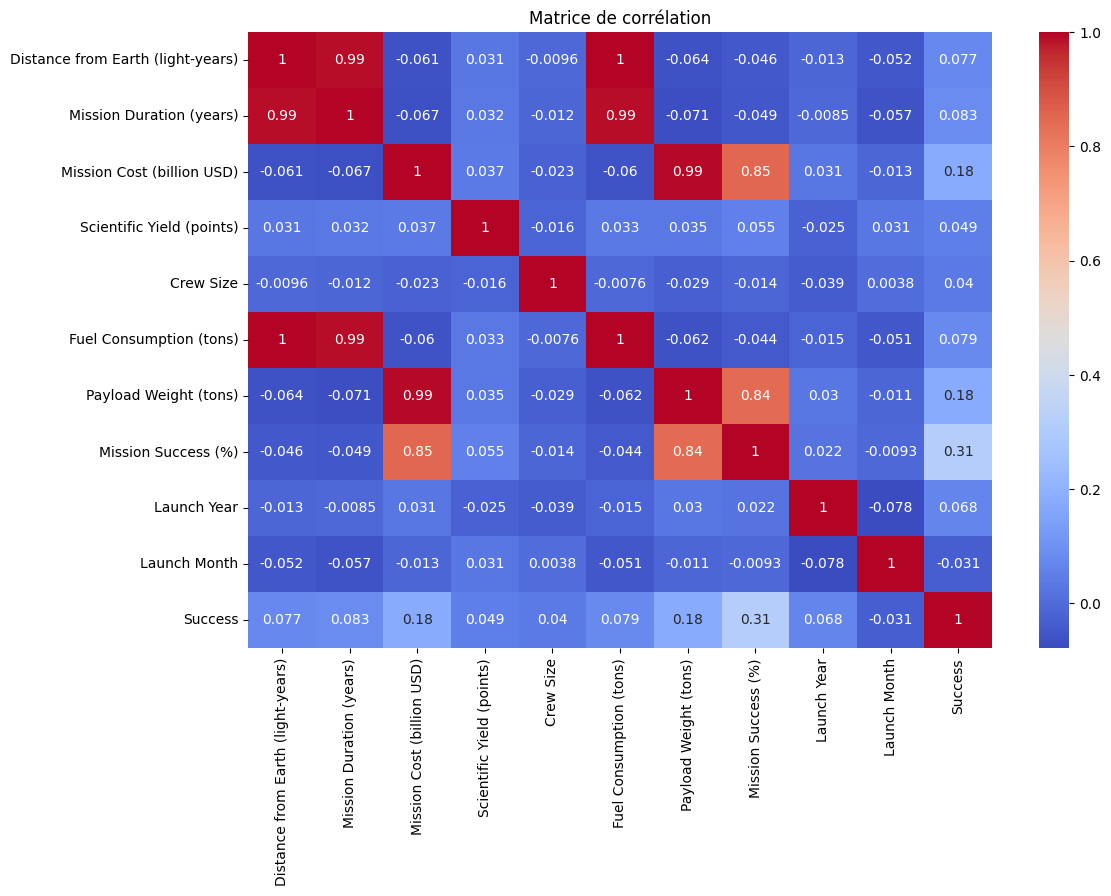

In [ ]:
# Matrice de corrélation
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

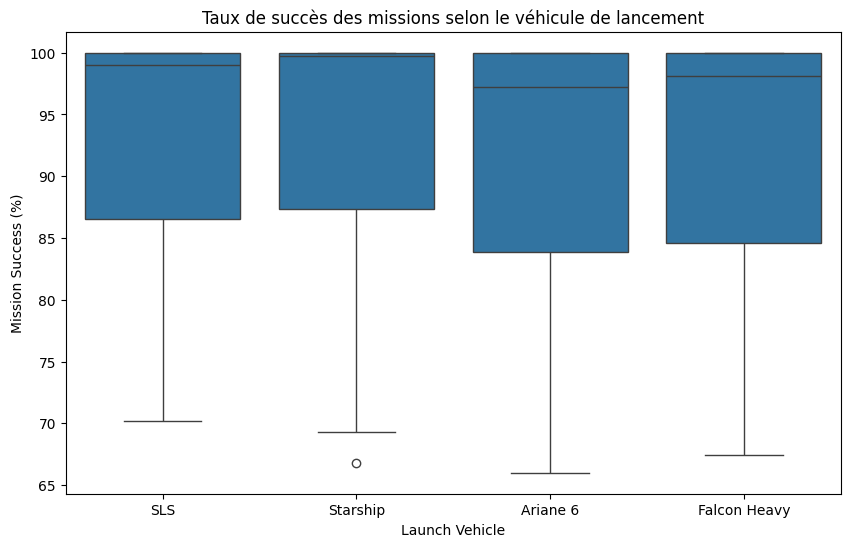

In [ ]:
# Taux de succès selon véhicule de lancement
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Launch Vehicle', y='Mission Success (%)')
plt.title("Taux de succès des missions selon le véhicule de lancement")
plt.show()